In [1]:
%load_ext autoreload
%autoreload 2

# XTCAV Processing: Physical Units - temp patch

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import psana

# XTCAV Processor Class
from xtcav_processor import XTCAVProcessor
from xtcav_dark_reference import XTCAVDarkReference
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

# Analysis

In [3]:
# Set params
# ----------

runnum_dark = 152
runnum_lasingoff = 153
runnum_lasingon = 156

fov = 180,320

## Dark Reference

XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting up data run times...
Done.


Setting data source types...: 3280it [00:01, 3004.58it/s]                        


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


Calculating dark reference:  99%|█████████▉| 99/100 [00:01<00:00, 58.13it/s]



Maximum number of images processed



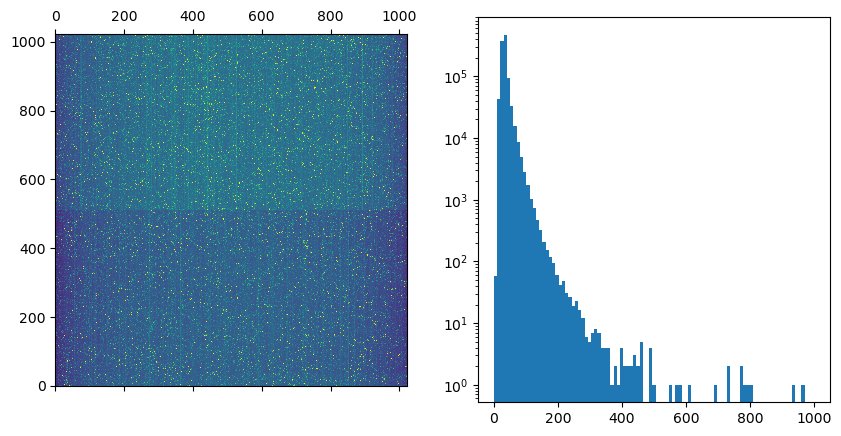

In [4]:
# Create object
xtdr = XTCAVDarkReference(get_datasource(runnum_dark), max_shots=100)

# Show
xtdr.show(
    vrange = (0,1e2),
    bins = np.linspace(0,1000,100)
)

## Lasing-off reference

XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting up data run times...
Done.


Setting data source types...: 5247it [00:00, 6148.48it/s]                        


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>
Looping through the first 3 good events...
Showing good shot #1 at time index 154:


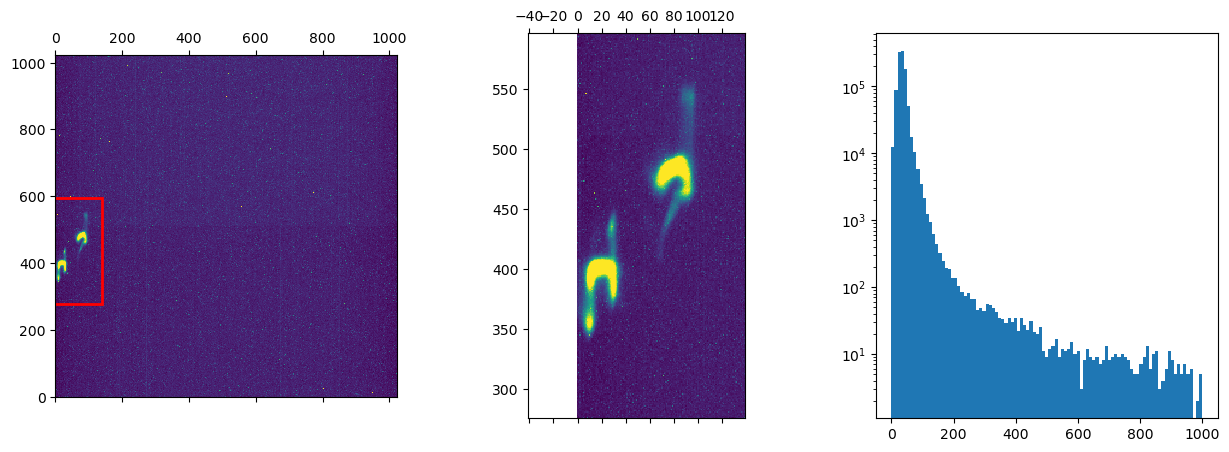

Showing good shot #2 at time index 155:


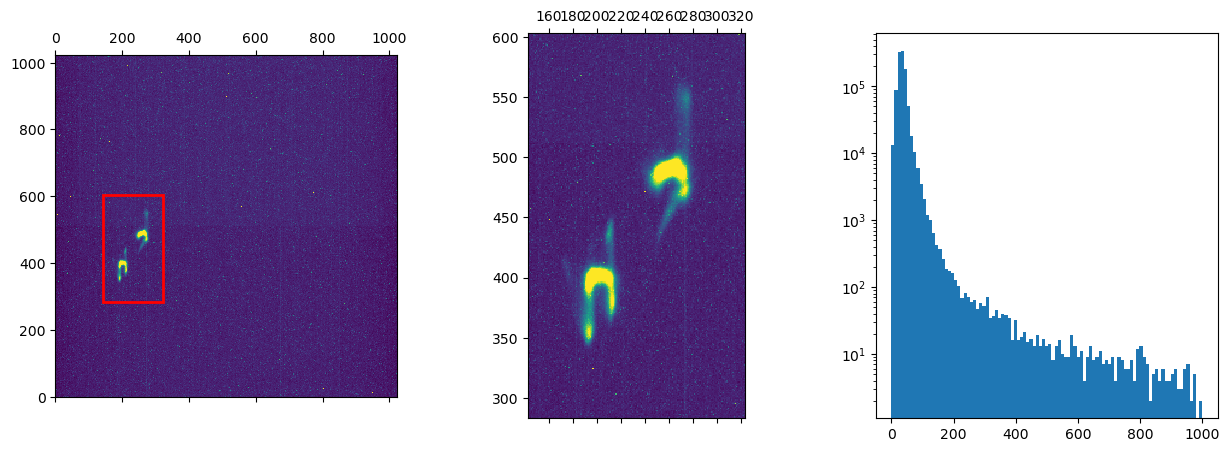

Showing good shot #3 at time index 156:


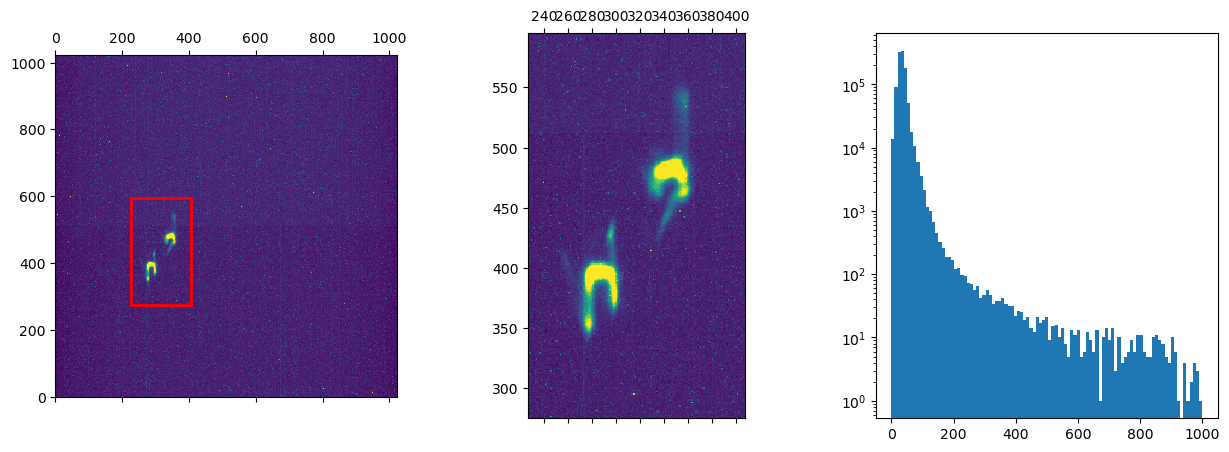

In [5]:
# Create object
xtpr = XTCAVProcessor(get_datasource(runnum_lasingoff))

# Show data
n_shots_show = 3

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov)

    # continue?
    if idx>=n_shots_show-1:
        break

Looping through the first 3 good events...
Showing good shot #1 at time index 154:


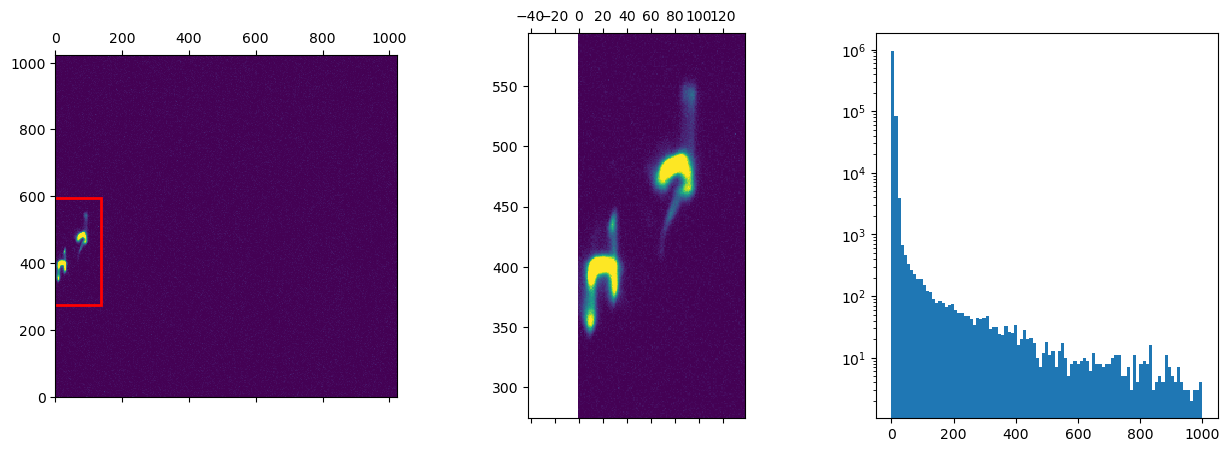

Showing good shot #2 at time index 155:


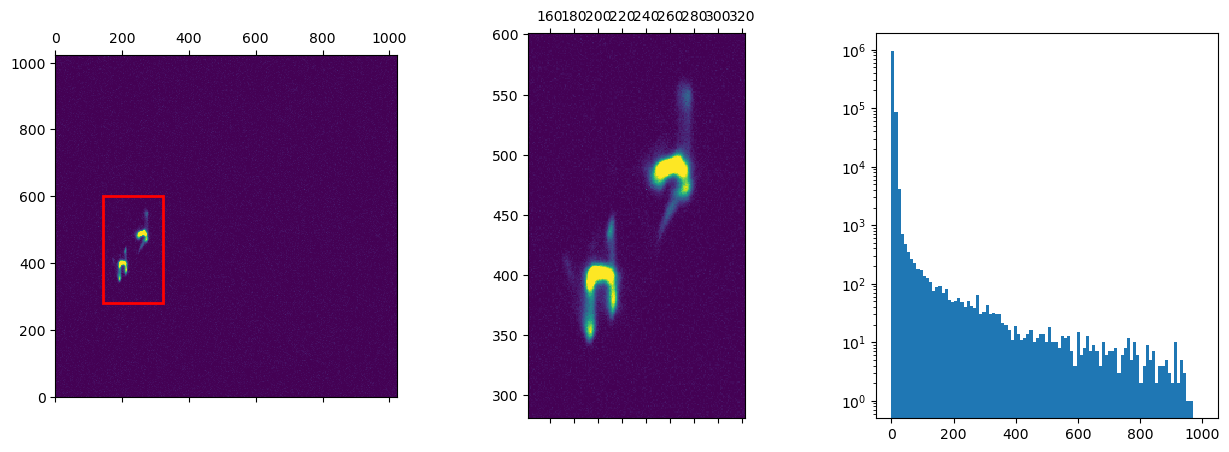

Showing good shot #3 at time index 156:


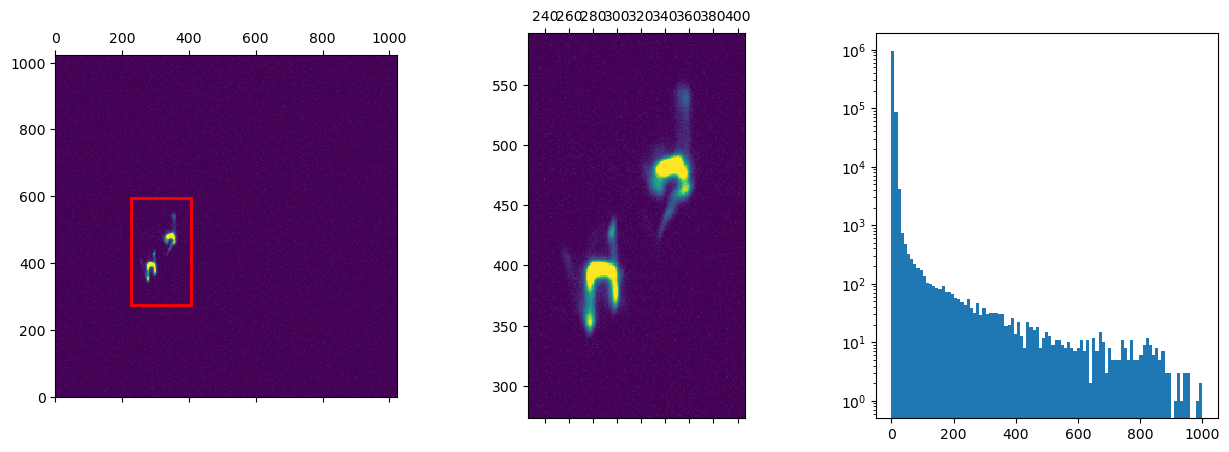

In [6]:
# Background subtraction

# Set dark ref
xtpr.set_darkreference(xtdr)

# Show
xtpr.reset_shot_iterator()
n_shots_show = 3

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov,preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

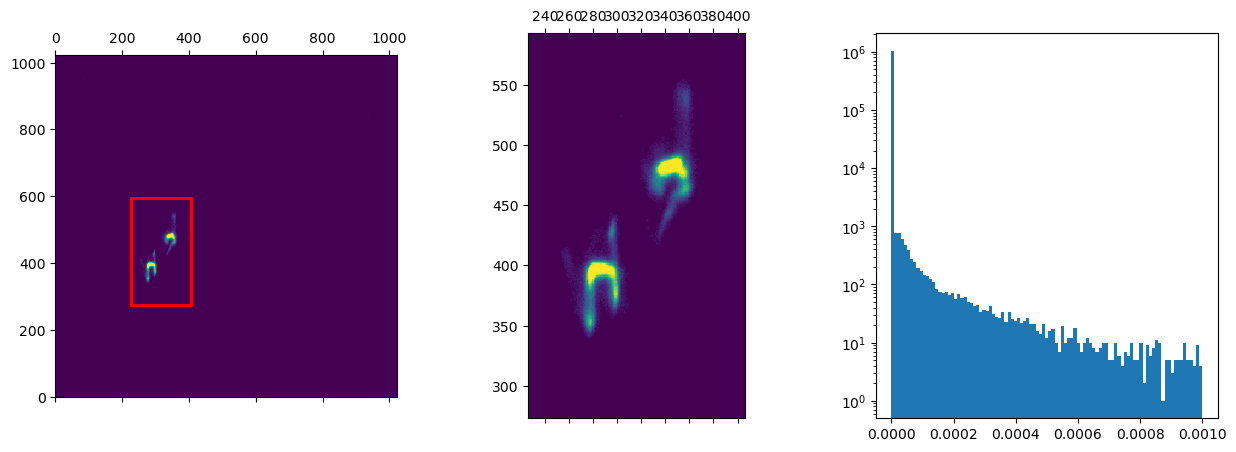

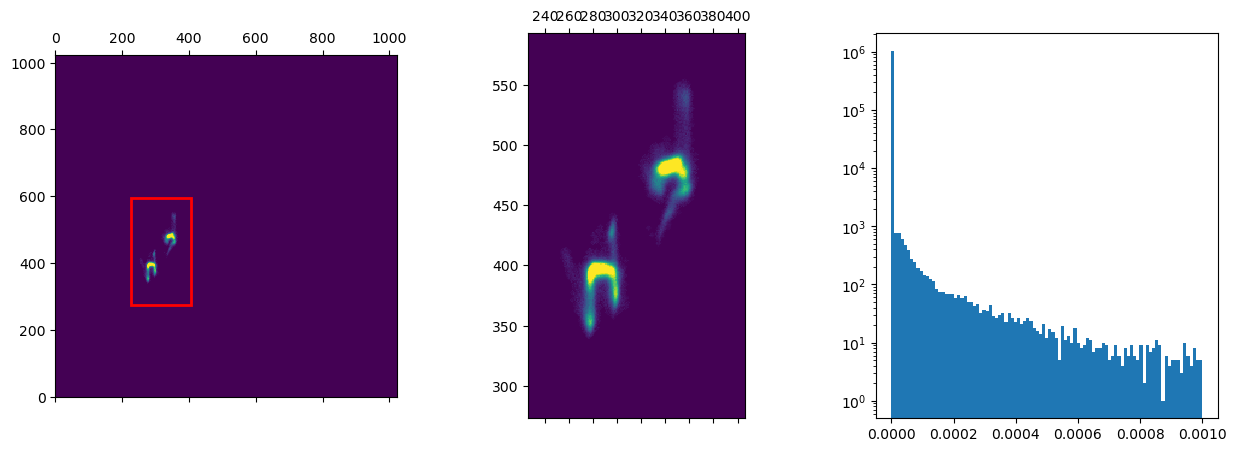

In [7]:
# Denoise

# ...with default denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(),
    vrange=(0,6e-4),bins=np.linspace(0,1e-3,100),fov=fov)

# ...with tweaked denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(nstd=1,close=2),
    vrange=(0,6e-4),bins=np.linspace(0,1e-3,100),fov=fov)

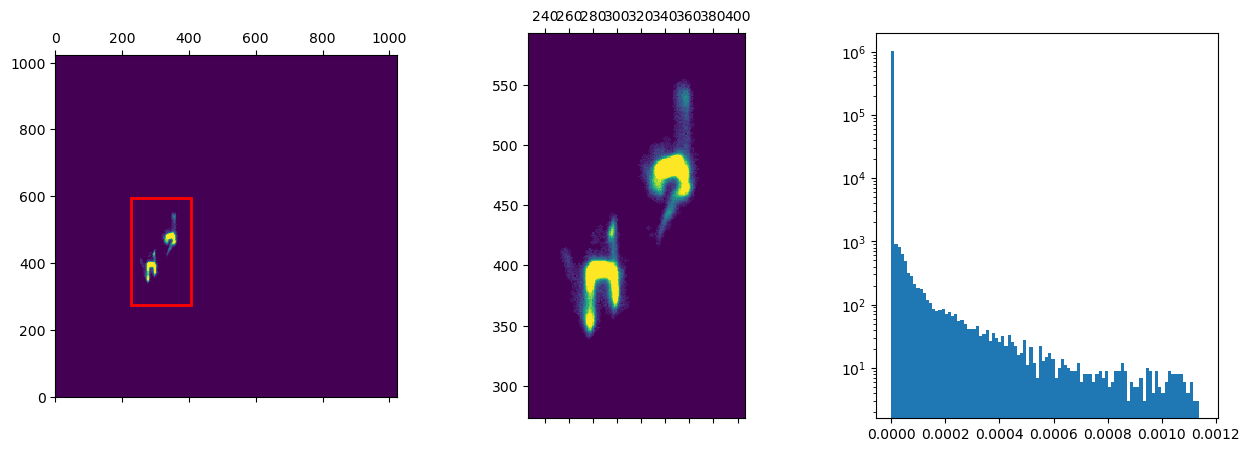

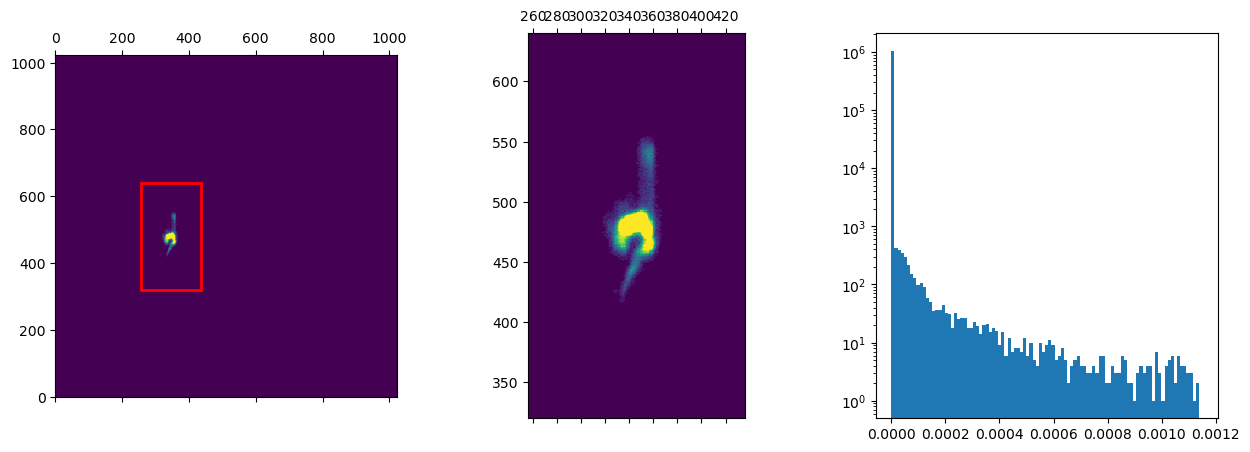

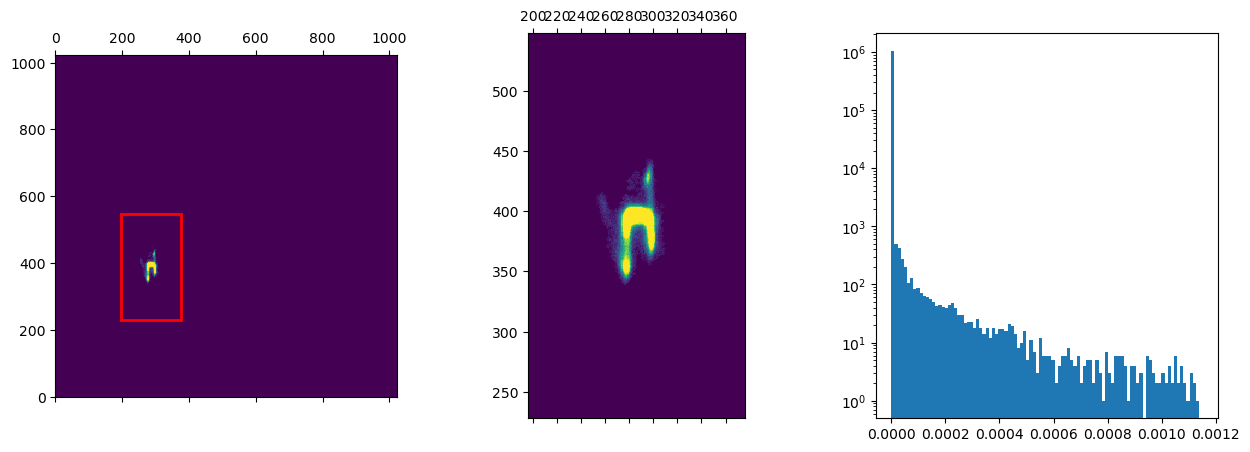

In [8]:
# Split images

# Get denoised frame, split the pulses
im = xtpr.get_frame_denoised_current(nstd=1,close=2)
ims = xtpr.split_frame(im,2)

# Show
xtpr.show_frame(im,vrange=(0,3e-4),bins=np.linspace(0,1.15e-3,100),fov=fov,)
xtpr.show_frame(ims[0],vrange=(0,3e-4),bins=np.linspace(0,1.15e-3,100),fov=fov,)
xtpr.show_frame(ims[1],vrange=(0,3e-4),bins=np.linspace(0,1.15e-3,100),fov=fov,)

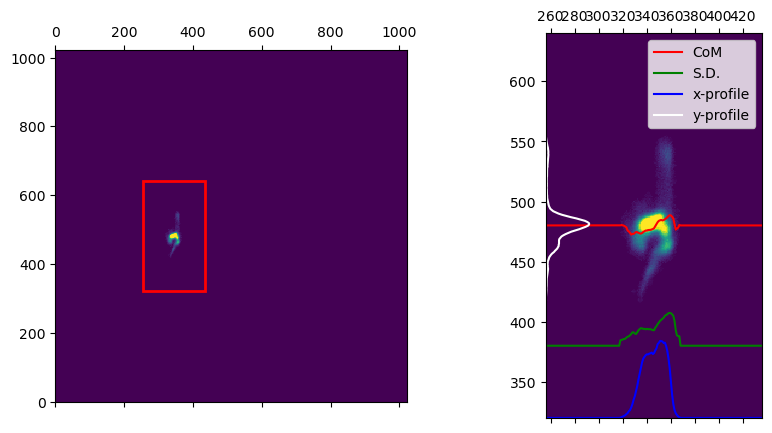

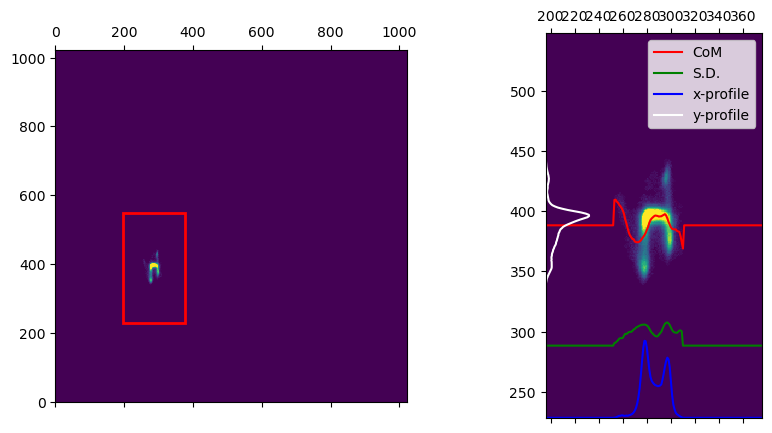

In [9]:
# Get image statistics

frame1,frame2 = ims[0],ims[1]

imageStats1 = xtpr.get_pulse_statistics(frame1)
imageStats2 = xtpr.get_pulse_statistics(frame2)
xtpr.show_frame_statistics(frame1,imageStats1,vrange=(0,6e-4),fov=fov,profiles=True)
xtpr.show_frame_statistics(frame2,imageStats2,vrange=(0,6e-4),fov=fov,profiles=True)

# Get physical units - hardcoded (patch)

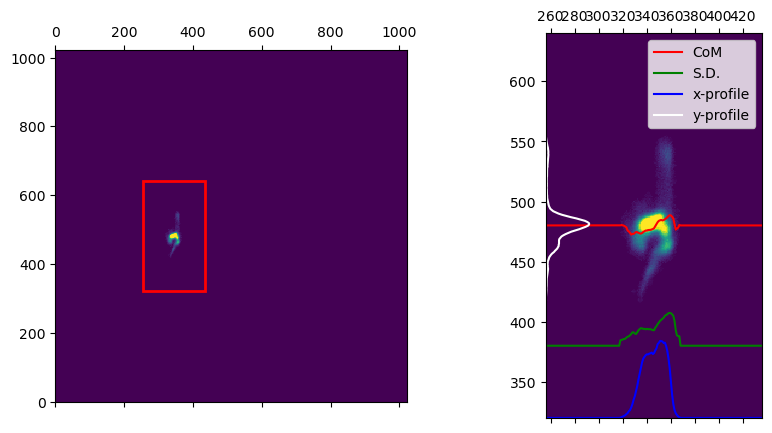

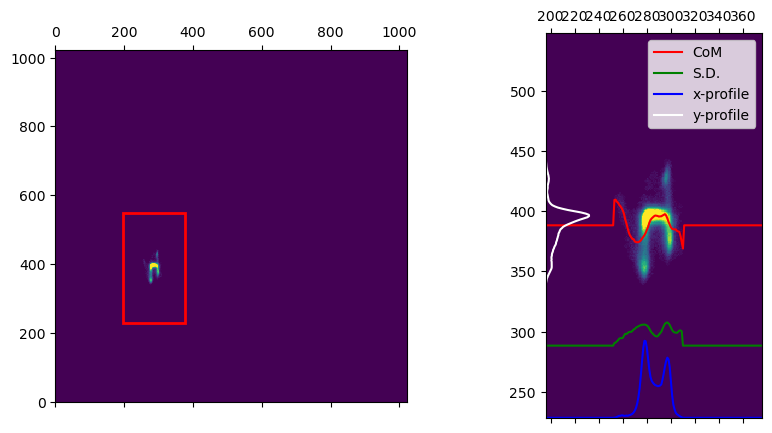

{'yMeVPerPix': 1.0, 'xfsPerPix': 1.0, 'xfs': array([-346.00190476, -345.00190476, -344.00190476, ...,  674.99809524,
        675.99809524,  676.99809524]), 'yMeV': array([-480.17500783, -479.17500783, -478.17500783, ...,  540.82499217,
        541.82499217,  542.82499217])}


/sdf/home/b/bsavitzk/L-10376/XTCAV/xtcav_processor.py:1177: UserWarning: Hardcoded calibrations are not yet calculated - returning uncalibrated axes!
  warnings.warn("Hardcoded calibrations are not yet calculated - returning uncalibrated axes!")


In [10]:
# Get event data
ebeam, gasdetector, frame = xtpr.get_data(evt)
shotToShot,ok = xtpr._get_shot_to_shot_parameters(ebeam,gasdetector)
assert(ok), "Shot-to-shot parameter recovery error!"

# Prepare pulse images 
im = xtpr.get_frame_denoised_current(nstd=1,close=2)
ims = xtpr.split_frame(im,2)
frame1,frame2 = ims[0],ims[1]

# Get statistics
imageStats1 = xtpr.get_pulse_statistics(frame1)
imageStats2 = xtpr.get_pulse_statistics(frame2)
xtpr.show_frame_statistics(frame1,imageStats1,vrange=(0,6e-4),fov=fov,profiles=True)
xtpr.show_frame_statistics(frame2,imageStats2,vrange=(0,6e-4),fov=fov,profiles=True)

# Get physical units
#physical_units, ok = xtpr.calculate_physical_units(   # this line should be used once we have the correct metadata
physical_units, ok = xtpr.get_physical_units_HARDCODED(
    center = np.array([imageStats1['xCOM'],imageStats1['yCOM']]),
    shotToShot = shotToShot
)
assert(ok), "Physical unit calibration error!"

print(physical_units)